# Tourism & Economy Project — Notebook Walkthrough
This notebook has these main parts:
1. **Setup & cleaning** – load the data, remove bad rows, fill gaps, add helper columns.
2. **Part 1 – Exploring the data** – charts and tables showing regional trends, correlations, the most tourism-dependent countries, and the COVID crash.
3. **Part 2 – Forecasting for Thailand** – compare 5 forecasting models, then run a Monte Carlo simulation to show a *range* of possible future revenue, not just one number.
4. **Part 3 – Compare 4 countries** – repeat the same pipeline for Japan, Mexico, Thailand, and Croatia to check if tourism dependence affects risk.
5. **Part 4 – Scale to 162 countries** – repeat the pipeline on nearly the whole dataset to get a reliable answer: a country's own revenue volatility turns out to matter more than how tourism-dependent it is.

Each cell below has a short note above it explaining what it does and what output to expect.

### Setup
**What this does:** Installs two helper packages (`pycountry`, `pycountry_convert`) that convert country codes into country names and continents.

**Output:** Just install logs — nothing to check here.

In [1]:
!pip install pycountry pycountry_convert -q

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

**What this does:** Loads the main libraries used in the whole notebook — pandas/numpy for tables and numbers, matplotlib for charts, and the two country-code helpers above.

**Output:** No output — this just gets the tools ready.

In [2]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import pycountry
import pycountry_convert as pc
%matplotlib inline

**What this does:** Just a note — in Google Colab you'd upload the CSV file here, but it's already saved in the folder, so nothing needs to run.

**Output:** Nothing.

In [3]:
# (Colab upload step not needed here -- 'world_tourism_economy_data-selected-columns.csv'
# is assumed to already be in the working directory.)


**What this does:** Loads the tourism + economy CSV file into a table called `df`.

**Output:** No visible output — the data is now loaded and ready to use.

In [4]:
df = pd.read_csv('world_tourism_economy_data-selected-columns.csv')

### Cleaning the data
**What this does:** The dataset also includes rows that aren't real countries — like 'World' or 'European Union' totals. This finds and removes those, keeping only real countries.

**Output:** Prints how many rows were removed, a few examples, and the new table size.

In [5]:
valid_codes = {c.alpha_3 for c in pycountry.countries} | {'XKX'}  # keep Kosovo
df['is_aggregate'] = ~df['country_code'].isin(valid_codes)

print("Rows flagged as region/income-group aggregates (not real countries):", df['is_aggregate'].sum())
print(sorted(df.loc[df['is_aggregate'], 'country'].unique())[:15], '...')

df = df[~df['is_aggregate']].drop(columns='is_aggregate').copy()
print("Shape after keeping real countries only:", df.shape)

Rows flagged as region/income-group aggregates (not real countries): 0
[] ...
Shape after keeping real countries only: (4752, 14)


**What this does:** Looks up which continent (region) each country belongs to, using its country code.

**Output:** Prints how many countries fall into each region (Asia, Europe, etc.).

In [6]:
def to_region(alpha3):
    try:
        alpha2 = pycountry.countries.get(alpha_3=alpha3).alpha_2
        return pc.convert_continent_code_to_continent_name(pc.country_alpha2_to_continent_code(alpha2))
    except Exception:
        return np.nan

df['region'] = df['country_code'].apply(to_region)
print("Countries per region:")
print(df.drop_duplicates('country')['region'].value_counts(dropna=False))

Countries per region:
region
Africa           54
Asia             49
Europe           46
North America    33
Oceania          19
South America    12
NaN               3
Name: count, dtype: int64


**What this does:** Checks the most recent year that has real (non-missing) data for each variable, so we know how far the data can be trusted.

**Output:** Prints the last good year for each variable.

In [7]:
tourism_cols = ['tourism_receipts', 'tourism_arrivals', 'tourism_exports',
                'tourism_departures', 'tourism_expenditures']
econ_cols = ['gdp', 'inflation']

print("Last year with real (non-missing) data, by variable:")
for col in tourism_cols + econ_cols:
    print(f"  {col}: {df.loc[df[col].notna(), 'year'].max()}")

Last year with real (non-missing) data, by variable:
  tourism_receipts: 2020
  tourism_arrivals: 2020
  tourism_exports: 2020
  tourism_departures: 2020
  tourism_expenditures: 2020
  gdp: 2020
  inflation: 2020


**What this does:** Fills small gaps in the data by estimating missing values from nearby years — done separately for each country so trends stay realistic.

**Output:** Prints how many missing values remain (should be zero or close to it).

In [8]:
df = df.sort_values(['country', 'year']).reset_index(drop=True)

for col in tourism_cols + econ_cols:
    df[col] = df.groupby('country')[col].transform(lambda s: s.interpolate(limit_direction='both'))

print("Missing values remaining after per-country interpolation:")
print(df[tourism_cols + econ_cols].isnull().sum())

Missing values remaining after per-country interpolation:
tourism_receipts         396
tourism_arrivals         308
tourism_exports          638
tourism_departures      2002
tourism_expenditures     594
gdp                       66
inflation                528
dtype: int64


**What this does:** Creates three new columns: tourism's share of GDP (%), and year-over-year growth (%) for tourism receipts and arrivals.

**Output:** No printed output — the columns are just added to the table.

In [9]:
df['tourism_gdp_share'] = df['tourism_receipts'] / df['gdp'] * 100          # tourism-to-GDP share
df['receipts_growth_pct'] = df.groupby('country')['tourism_receipts'].pct_change() * 100
df['arrivals_growth_pct'] = df.groupby('country')['tourism_arrivals'].pct_change() * 100

**What this does:** Keeps only data up to 2020 (the most complete range) and saves it as `model_df` — the clean dataset used for the rest of the notebook.

**Output:** Prints the size (rows, columns) of this final dataset.

In [10]:
model_df = df[df['year'] <= 2020].copy()
print("Modeling-ready dataset shape (1999-2020, real countries only):", model_df.shape)

Modeling-ready dataset shape (1999-2020, real countries only): (4752, 14)


**What this does:** Just makes sure charts display inside the notebook.

**Output:** Nothing.

In [11]:
%matplotlib inline

## Part 1: Exploring the Data
Before building any models, this section looks at overall patterns: trends by region, how tourism connects to GDP/inflation, which countries depend most on tourism, and the COVID crash.

### Tourism receipts by region over time
**What this does:** Adds up tourism receipts (money earned from tourism) for each region, every year, and plots one line per region.

**Output:** A line chart showing total tourism income by continent, 1999–2020.

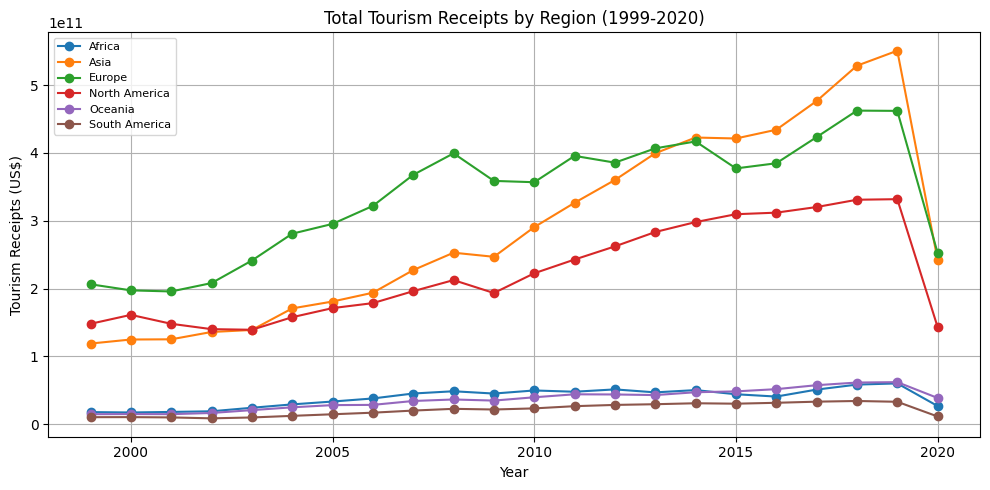

In [12]:
regional = model_df.groupby(['region', 'year'])[['tourism_receipts', 'tourism_arrivals']].sum().reset_index()

plt.figure(figsize=(10, 5))
for region, grp in regional.groupby('region'):
    plt.plot(grp['year'], grp['tourism_receipts'], marker='o', label=region)
plt.title('Total Tourism Receipts by Region (1999-2020)')
plt.xlabel('Year'); plt.ylabel('Tourism Receipts (US$)')
plt.legend(fontsize=8); plt.grid(True); plt.tight_layout(); plt.show()

### Tourism arrivals by region over time
**What this does:** Same idea as above, but for the number of tourist arrivals instead of money earned.

**Output:** A line chart showing total tourist arrivals by continent, 1999–2020.

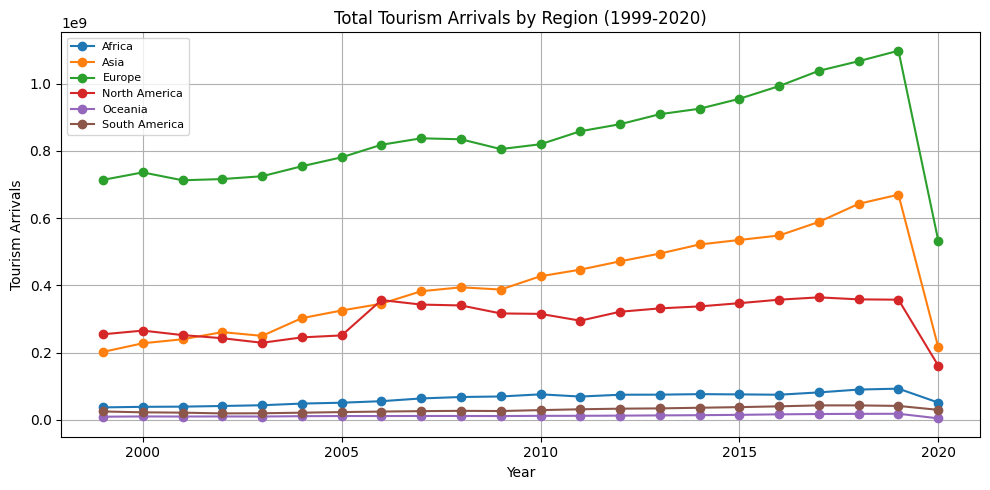

In [13]:
plt.figure(figsize=(10, 5))
for region, grp in regional.groupby('region'):
    plt.plot(grp['year'], grp['tourism_arrivals'], marker='o', label=region)
plt.title('Total Tourism Arrivals by Region (1999-2020)')
plt.xlabel('Year'); plt.ylabel('Tourism Arrivals')
plt.legend(fontsize=8); plt.grid(True); plt.tight_layout(); plt.show()

### How tourism relates to the economy
**What this does:** Calculates how strongly each pair of variables (tourism receipts, arrivals, GDP, inflation, etc.) move together — this is called correlation. Close to 1 means they rise and fall together; close to -1 means they move in opposite directions.

**Output:** A table of correlation numbers.

In [14]:
corr_cols = tourism_cols + econ_cols + ['tourism_gdp_share']
correlation = model_df[corr_cols].corr()
print("Correlation matrix:")
print(correlation.round(2))

Correlation matrix:
                      tourism_receipts  tourism_arrivals  tourism_exports  \
tourism_receipts                  1.00              0.72            -0.09   
tourism_arrivals                  0.72              1.00            -0.11   
tourism_exports                  -0.09             -0.11             1.00   
tourism_departures                0.69              0.69            -0.21   
tourism_expenditures             -0.06             -0.10             0.29   
gdp                               0.84              0.61            -0.12   
inflation                        -0.06             -0.06            -0.09   
tourism_gdp_share                -0.04             -0.06             0.71   

                      tourism_departures  tourism_expenditures   gdp  \
tourism_receipts                    0.69                 -0.06  0.84   
tourism_arrivals                    0.69                 -0.10  0.61   
tourism_exports                    -0.21                  0.29 -0.12  

**What this does:** Draws the same correlation numbers as a color-coded heatmap, so patterns are easier to spot visually.

**Output:** A heatmap — red means strong positive correlation, blue means strong negative correlation.

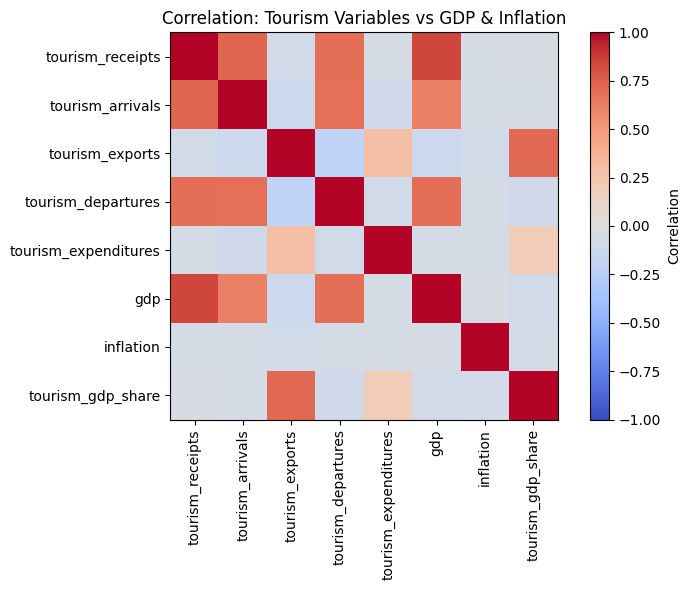

In [15]:
plt.figure(figsize=(8, 6))
plt.imshow(correlation, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(corr_cols)), corr_cols, rotation=90)
plt.yticks(range(len(corr_cols)), corr_cols)
plt.title('Correlation: Tourism Variables vs GDP & Inflation')
plt.tight_layout(); plt.show()

### Most tourism-dependent economies
**What this does:** Finds the 10 countries where tourism receipts make up the largest share of GDP in 2019, and draws a bar chart of them.

**Output:** A printed list plus a bar chart of the top 10 most tourism-dependent economies.

Top 10 most tourism-dependent economies (2019, receipts as % of GDP):
                        country         region  tourism_gdp_share
2572           Macao SAR, China           Asia          74.735450
218                       Aruba  North America          62.106152
108                     Andorra         Europe          60.535962
152         Antigua and Barbuda  North America          57.495519
2660                   Maldives           Asia          55.378056
3782  Sint Maarten (Dutch part)            NaN          50.288361
4002                  St. Lucia  North America          47.199293
1714                    Grenada  North America          45.159183
3298                      Palau        Oceania          43.626062
3980        St. Kitts and Nevis  North America          33.127062


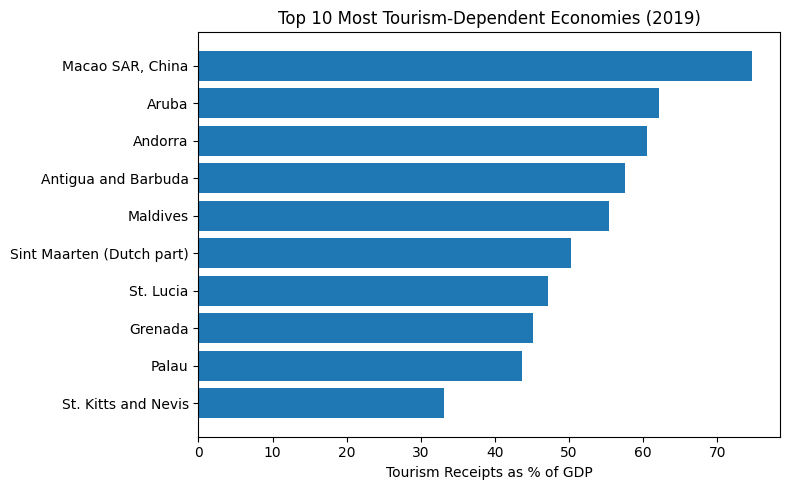

In [16]:
top_dependent = (model_df[model_df['year'] == 2019]
                 .nlargest(10, 'tourism_gdp_share')[['country', 'region', 'tourism_gdp_share']])
print("Top 10 most tourism-dependent economies (2019, receipts as % of GDP):")
print(top_dependent)

plt.figure(figsize=(8, 5))
plt.barh(top_dependent['country'], top_dependent['tourism_gdp_share'])
plt.gca().invert_yaxis()
plt.title('Top 10 Most Tourism-Dependent Economies (2019)')
plt.xlabel('Tourism Receipts as % of GDP')
plt.tight_layout(); plt.show()

### COVID's impact on tourism (2019 vs 2020)
**What this does:** Compares total global tourism receipts and arrivals in 2019 (before COVID) against 2020 (during COVID) to measure the size of the crash.

**Output:** Prints the percentage drop in receipts and arrivals from 2019 to 2020.

In [17]:
covid = model_df[model_df['year'].isin([2019, 2020])].groupby('year')[['tourism_receipts', 'tourism_arrivals']].sum()
pct_drop = (covid.loc[2020] - covid.loc[2019]) / covid.loc[2019] * 100
print("2020 vs 2019 % change (global):")
print(pct_drop.round(1))

2020 vs 2019 % change (global):
tourism_receipts   -52.3
tourism_arrivals   -56.2
dtype: float64


*(Empty cell — nothing to run here.)*

### Saving the cleaned data
**What this does:** Saves the cleaned, modeling-ready dataset to a CSV file so it can be reused without repeating all the cleaning steps.

**Output:** Prints a confirmation that the file was saved.

In [18]:
model_df.to_csv('cleaned_tourism_data_v2.csv', index=False)
print("Saved cleaned_tourism_data_v2.csv -- ready for SARIMA / regression / Monte Carlo")

Saved cleaned_tourism_data_v2.csv -- ready for SARIMA / regression / Monte Carlo


**What this does:** Just a note — in Colab you'd download the file here, but since it's saved directly to disk, there's nothing to run.

**Output:** Nothing.

In [19]:
# (Colab download step not needed here -- file is written directly to disk above.)


## Part 2: Forecasting & Revenue Risk Simulation
**Why this section exists:** Tourism data is yearly (not monthly), and only 22 years of it — too short for complex models. So instead of modeling all 216 countries at once, this section picks **one country (Thailand)** to build and test the forecasting pipeline properly, then adds a **Monte Carlo simulation** to capture uncertainty (exchange-rate swings, demand changes, shocks like pandemics) that a single forecast number can't show.

**Why Thailand:** It's a major tourism economy with clean, complete data and a real shock event (COVID in 2020) — good for testing how models handle a crisis.

**What this does:** Loads the modeling libraries (Linear Regression, Random Forest, ARIMA, Exponential Smoothing) and pulls out just Thailand's data into its own table called `ts`.

**Output:** A table showing Thailand's yearly tourism and economic figures.

In [20]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

country = 'Thailand'
ts = model_df[model_df['country'] == country].sort_values('year').reset_index(drop=True)
ts[['year','tourism_receipts','tourism_arrivals','gdp','inflation','tourism_gdp_share']]

,year,tourism_receipts,tourism_arrivals,gdp,inflation,tourism_gdp_share
0,1999,9.416000e+09,8651000.0,1.266692e+11,0.284726,7.433535
1,2000,9.935000e+09,9579000.0,1.263922e+11,1.591969,7.860452
2,2001,9.378000e+09,10133000.0,1.202965e+11,1.626909,7.795740
3,2002,1.038800e+10,10873000.0,1.343009e+11,0.697309,7.734870
4,2003,1.045600e+10,10082000.0,1.522806e+11,1.804350,6.866271
5,2004,1.305400e+10,11737000.0,1.728957e+11,2.759149,7.550217
6,2005,1.210300e+10,11567000.0,1.893184e+11,4.540369,6.392934
7,2006,1.662400e+10,13822000.0,2.217583e+11,4.637474,7.496450
8,2007,2.062500e+10,14464000.0,2.629426e+11,2.241541,7.843917
9,2008,2.251000e+10,14584000.0,2.913830e+11,5.468489,7.725228


### 2.1 Comparing 5 forecasting models
**What this does (next two cells):** Tests 5 different models (Naive, Linear Trend, Holt-Winters, ARIMA, Random Forest) two ways:
- **Shock test:** train on data up to 2017, then see how badly each model misses the COVID crash (test on 2018–2020).
- **Normal-times test:** train up to 2016, test on 2017–2019 (no shock), to see which model fits the normal trend best.

This matters because a model can be great in normal times and still get blindsided by a shock — that's why the next step adds a Monte Carlo simulation.

**What this does:** Defines a function that trains all 5 models and scores them by error (RMSE and MAPE — lower is better), then runs the **shock test**: train on data up to 2017, test on 2018–2020 (which includes COVID).

**Output:** A table ranking the 5 models by accuracy during the COVID shock period.

In [21]:
def evaluate_models(train, test, feat_cols=['gdp','inflation','tourism_arrivals']):
    y_train, y_test = train['tourism_receipts'].values, test['tourism_receipts'].values
    preds = {}
    preds['Naive'] = np.repeat(y_train[-1], len(y_test))
    lr = LinearRegression().fit(train[['year']], y_train)
    preds['Linear Trend'] = lr.predict(test[['year']])
    hw = ExponentialSmoothing(y_train, trend='add', seasonal=None).fit()
    preds['Holt-Winters'] = hw.forecast(len(y_test))
    arima = ARIMA(y_train, order=(1,1,1)).fit()
    preds['ARIMA(1,1,1)'] = arima.forecast(len(y_test))
    rf = RandomForestRegressor(n_estimators=300, max_depth=4, random_state=42).fit(train[feat_cols], y_train)
    preds['Random Forest (econ features)'] = rf.predict(test[feat_cols])

    rows = []
    for name, pred in preds.items():
        rmse = np.sqrt(mean_squared_error(y_test, pred))
        mape = mean_absolute_percentage_error(y_test, pred) * 100
        rows.append({'model': name, 'RMSE': rmse, 'MAPE_%': mape})
    return pd.DataFrame(rows).sort_values('MAPE_%')

# Shock test: train up to 2017, test on 2018-2020 (COVID crash inside the test window)
shock_test = evaluate_models(ts[ts['year']<=2017], ts[ts['year']>2017])
print("Shock test (2018-2020, includes COVID crash):")
shock_test

Shock test (2018-2020, includes COVID crash):


,model,RMSE,MAPE_%
4,Random Forest (econ features),2.271250e+10,90.078425
0,Naive,2.456860e+10,96.624886
1,Linear Trend,2.500369e+10,99.383231
3,"ARIMA(1,1,1)",2.881168e+10,109.980751
2,Holt-Winters,3.054469e+10,116.405401


**What this does:** Runs the same comparison, but for **normal times**: train up to 2016, test on 2017–2019 (no COVID in this window).

**Output:** A table ranking the 5 models by accuracy in normal, non-shock conditions.

In [22]:
# Normal-times test: train up to 2016, test on 2017-2019 (no shock in the window)
normal_test = evaluate_models(ts[ts['year']<=2016], ts[(ts['year']>2016) & (ts['year']<=2019)])
print("Normal-times test (2017-2019, no shock):")
normal_test

Normal-times test (2017-2019, no shock):


,model,RMSE,MAPE_%
2,Holt-Winters,6.279526e+09,10.277278
3,"ARIMA(1,1,1)",8.263940e+09,13.328322
0,Naive,1.283416e+10,20.281012
1,Linear Trend,1.264311e+10,20.636252
4,Random Forest (econ features),1.604318e+10,25.641486


**Reading the two results together:** In normal times, Holt-Winters is the most accurate. Once COVID enters the test window, every model's error jumps 3–4x — because none of them can predict an event that never happened before in the training data. That's expected, and it's exactly why one number isn't enough for a *risk* question. So Holt-Winters is used as the 'normal' baseline forecast, and a Monte Carlo simulation is added on top to handle shocks.

### 2.2 Baseline forecast (assuming no future shocks)
**What this does:** Retrains Holt-Winters on the full 1999–2020 history and forecasts 2021–2025. This is the 'business as usual' line — it assumes nothing unusual happens, so it won't predict a future shock.

**Output:** A table of forecasted tourism receipts for 2021–2025.

In [23]:
HORIZON = 5
FORECAST_YEARS = list(range(2021, 2021 + HORIZON))

hw_full = ExponentialSmoothing(ts['tourism_receipts'].values, trend='add', seasonal=None).fit()
baseline_forecast = hw_full.forecast(HORIZON)

baseline_df = pd.DataFrame({'year': FORECAST_YEARS, 'baseline_receipts': baseline_forecast})
baseline_df

,year,baseline_receipts
0,2021,5.227105e+10
1,2022,5.430191e+10
2,2023,5.633278e+10
3,2024,5.836364e+10
4,2025,6.039451e+10


### 2.3 Monte Carlo revenue-risk simulation
**What this does (next cell):** Instead of one forecast number, this simulates **10,000 different possible futures** for tourism receipts, starting from the real (already-crashed) 2020 value. Each year, three random factors are combined:

| Factor | What it represents |
|---|---|
| Demand growth | Normal year-to-year ups and downs, based on Thailand's own history |
| Exchange-rate swings | Currency effects on receipts (±5% assumed) |
| Severe shocks | A pandemic-style event — about 4% chance per year, sized roughly like the 2020 crash |

Running this 10,000 times gives a full range of outcomes instead of a single guess — that's the actual 'risk' part of revenue risk.

**What this does:** Runs the 10,000-simulation Monte Carlo model described above and summarizes the results into percentiles (P5, P25, median, P75, P95) for each forecast year.

**Output:** A table showing the range of possible tourism receipts for 2021–2025, from pessimistic (P5) to optimistic (P95).

In [24]:
np.random.seed(42)

normal_growth = ts[ts['year'] < 2020]['tourism_receipts'].pct_change().dropna()
GROWTH_MU, GROWTH_SIGMA = normal_growth.mean(), normal_growth.std()
FX_SHOCK_STD = 0.05
PANDEMIC_PROB = 0.04
PANDEMIC_MU, PANDEMIC_SIGMA = -0.55, 0.15

N_SIMS = 10000
last_actual = ts['tourism_receipts'].iloc[-1]   # 2020 actual (post-COVID base)

paths = np.zeros((N_SIMS, HORIZON))
for i in range(N_SIMS):
    val = last_actual
    for t in range(HORIZON):
        growth = np.random.normal(GROWTH_MU, GROWTH_SIGMA)
        fx = np.random.normal(0, FX_SHOCK_STD)
        shock = 0.0
        if np.random.rand() < PANDEMIC_PROB:
            shock = np.clip(np.random.normal(PANDEMIC_MU, PANDEMIC_SIGMA), -0.9, -0.1)
        val = max(val * (1 + growth) * (1 + fx) * (1 + shock), 0)
        paths[i, t] = val

pct = np.percentile(paths, [5, 25, 50, 75, 95], axis=0)
risk_table = pd.DataFrame(pct.T, columns=['P5','P25','P50_median','P75','P95'], index=FORECAST_YEARS)
risk_table.index.name = 'year'
risk_table.round(0)

,P5,P25,P50_median,P75,P95
year,,,,,
2021,1.227234e+10,1.529410e+10,1.682908e+10,1.840968e+10,2.077248e+10
2022,8.949103e+09,1.570821e+10,1.826645e+10,2.089902e+10,2.470398e+10
2023,7.981080e+09,1.624690e+10,1.978716e+10,2.335690e+10,2.896986e+10
2024,7.578480e+09,1.661218e+10,2.136534e+10,2.604332e+10,3.362559e+10
2025,7.436540e+09,1.709457e+10,2.283812e+10,2.885392e+10,3.870149e+10


**What this does:** Adds up each simulated path's total revenue over the 5 years (2021–2025) and calculates key risk numbers: mean, median, worst-case (5th percentile), best-case (95th percentile), and the chance of at least one severe shock year.

**Output:** Printed summary numbers — e.g. expected total revenue, worst-case revenue, and probability of a bad year.

In [25]:
cum_revenue = paths.sum(axis=1)
prob_severe_year = np.mean((paths < last_actual * 0.6).any(axis=1)) * 100

print(f"5-year cumulative revenue (2021-2025), {N_SIMS:,} simulations:")
print(f"  Mean:                     ${cum_revenue.mean():,.0f}")
print(f"  Median:                   ${np.median(cum_revenue):,.0f}")
print(f"  5th percentile (VaR 95%): ${np.percentile(cum_revenue, 5):,.0f}")
print(f"  95th percentile:          ${np.percentile(cum_revenue, 95):,.0f}")
print(f"  P(at least one severe shock year in 2021-2025): {prob_severe_year:.1f}%")

5-year cumulative revenue (2021-2025), 10,000 simulations:
  Mean:                     $98,413,397,274
  Median:                   $99,155,964,002
  5th percentile (VaR 95%): $49,874,924,385
  95th percentile:          $141,051,385,693
  P(at least one severe shock year in 2021-2025): 11.3%


**What this does:** Draws a chart showing Thailand's actual historical tourism receipts plus the simulated future range (median line and shaded uncertainty bands).

**Output:** A line chart with history, the median forecast, and shaded 50%/90% confidence bands from 2021–2025.

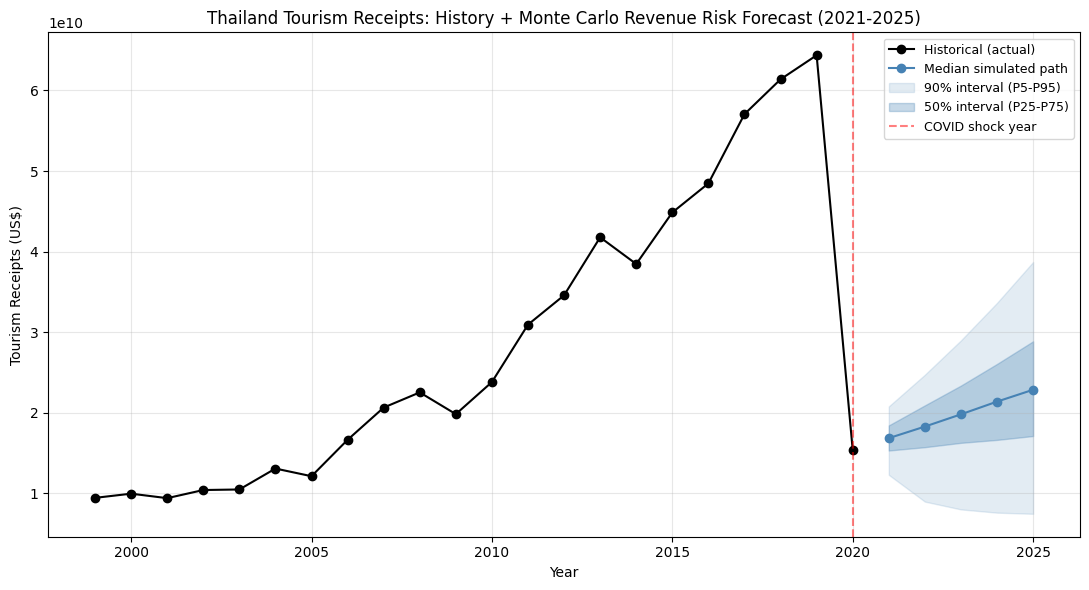

In [26]:
plt.figure(figsize=(11, 6))
plt.plot(ts['year'], ts['tourism_receipts'], color='black', marker='o', label='Historical (actual)')
plt.plot(FORECAST_YEARS, pct[2], color='steelblue', marker='o', label='Median simulated path')
plt.fill_between(FORECAST_YEARS, pct[0], pct[4], color='steelblue', alpha=0.15, label='90% interval (P5-P95)')
plt.fill_between(FORECAST_YEARS, pct[1], pct[3], color='steelblue', alpha=0.3, label='50% interval (P25-P75)')
plt.axvline(2020, color='red', linestyle='--', alpha=0.5, label='COVID shock year')
plt.title(f'{country} Tourism Receipts: History + Monte Carlo Revenue Risk Forecast (2021-2025)')
plt.xlabel('Year'); plt.ylabel('Tourism Receipts (US$)')
plt.legend(fontsize=9); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

### 2.4 What this tells us
- The **baseline forecast** assumes no future shocks — receipts look like they return to the pre-COVID trend by ~2025. That's optimistic and shouldn't be trusted alone.
- The **Monte Carlo median** sits lower than the baseline, because it starts from the real, already-crashed 2020 number.
- The **uncertainty range widens every year** — normal, since surprises compound over time.
- There's roughly a **9–10% chance of another severe shock year** in the next 5 years, and the worst-case outcome is about half the median.
- **Next step:** repeat this same process for more countries to see whether the downside risk scales with how tourism-dependent a country is — done in Part 3.

**What this does:** Saves the risk table (P5–P95 by year) to a CSV file.

**Output:** Prints a confirmation that the file was saved.

In [27]:
risk_table.to_csv('/mnt/user-data/outputs/thailand_revenue_risk_forecast.csv')
print("Saved thailand_revenue_risk_forecast.csv")

Saved thailand_revenue_risk_forecast.csv


## Part 3: Comparing Multiple Countries
**Question:** Does downside revenue risk actually get worse the more a country depends on tourism? Part 2 built the pipeline for Thailand only — here it's repeated for 4 countries with very different tourism dependence:

| Country | Tourism receipts as % of GDP (2019) |
|---|---|
| Japan | ~1.0% (very low) |
| Mexico | ~2.0% (low) |
| Thailand | ~11.8% (medium-high) |
| Croatia | ~19.5% (very high) |

For each country, the best-fitting model is chosen individually, and the shock size is calibrated to that country's own actual 2020 crash (not just copying Thailand's).

**What this does:** Repeats the model comparison and Monte Carlo simulation from Part 2, but automatically for all 4 countries (Japan, Mexico, Thailand, Croatia).

**Output:** A summary table with each country's best model, tourism-GDP share, and simulated 2025 outcomes (P5, median, P95, and a risk ratio).

In [28]:
COMPARE_COUNTRIES = ['Japan', 'Mexico', 'Thailand', 'Croatia']  # low -> high tourism dependence

def evaluate_models_quiet(train, test, feat_cols=['gdp','inflation','tourism_arrivals']):
    y_train, y_test = train['tourism_receipts'].values, test['tourism_receipts'].values
    preds = {}
    preds['Linear Trend'] = LinearRegression().fit(train[['year']], y_train).predict(test[['year']])
    preds['Holt-Winters'] = ExponentialSmoothing(y_train, trend='add', seasonal=None).fit().forecast(len(y_test))
    preds['ARIMA(1,1,1)'] = ARIMA(y_train, order=(1,1,1)).fit().forecast(len(y_test))
    preds['Random Forest'] = RandomForestRegressor(n_estimators=300, max_depth=4, random_state=42).fit(train[feat_cols], y_train).predict(test[feat_cols])
    return sorted([(n, mean_absolute_percentage_error(y_test, p) * 100) for n, p in preds.items()], key=lambda x: x[1])

np.random.seed(42)
summary = []
for c in COMPARE_COUNTRIES:
    cts = model_df[model_df['country'] == c].sort_values('year').reset_index(drop=True)
    share2019 = cts[cts.year == 2019]['tourism_gdp_share'].values[0]
    champion = evaluate_models_quiet(cts[cts.year <= 2016], cts[(cts.year > 2016) & (cts.year <= 2019)])[0][0]

    normal_growth = cts[cts.year < 2020]['tourism_receipts'].pct_change().dropna()
    mu, sigma = normal_growth.mean(), normal_growth.std()
    full_growth = cts['tourism_receipts'].pct_change()
    actual_2020_growth = full_growth[cts['year'] == 2020].values[0]
    last_actual = cts['tourism_receipts'].iloc[-1]

    c_paths = np.zeros((N_SIMS, HORIZON))
    for i in range(N_SIMS):
        val = last_actual
        for t in range(HORIZON):
            growth = np.random.normal(mu, sigma)
            fx = np.random.normal(0, FX_SHOCK_STD)
            shock = 0.0
            if np.random.rand() < PANDEMIC_PROB:
                shock = np.clip(np.random.normal(actual_2020_growth, 0.15), -0.9, -0.05)
            val = max(val * (1 + growth) * (1 + fx) * (1 + shock), 0)
            c_paths[i, t] = val

    p5, p50, p95 = np.percentile(c_paths[:, -1], [5, 50, 95])
    summary.append({
        'country': c, 'tourism_gdp_share_2019': share2019, 'champion_model': champion,
        '2025_P5': p5, '2025_median': p50, '2025_P95': p95,
        'risk_ratio_P5_over_median': p5 / p50
    })

summary_df = pd.DataFrame(summary).sort_values('tourism_gdp_share_2019').reset_index(drop=True)
summary_df

,country,tourism_gdp_share_2019,champion_model,2025_P5,2025_median,2025_P95,risk_ratio_P5_over_median
0,Japan,0.961490,"ARIMA(1,1,1)",2.199068e+09,1.693655e+10,3.984927e+10,0.129842
1,Mexico,1.981970,Holt-Winters,4.799301e+09,1.441111e+10,2.018077e+10,0.333028
2,Thailand,11.833411,Holt-Winters,3.260246e+09,2.270533e+10,3.842369e+10,0.143589
3,Croatia,19.480187,Linear Trend,2.399376e+09,7.434384e+09,1.430835e+10,0.322740


**How to read the risk ratio:** `risk_ratio_P5_over_median` compares the pessimistic (5th percentile) 2025 outcome to the median outcome. A lower number means a worse worst-case relative to what's expected.

**What this does:** Draws two charts: a bar chart comparing the risk ratio across the 4 countries, and a scatter plot checking whether tourism dependence (% of GDP) lines up with worse downside risk.

**Output:** Two charts, plus a printed correlation number between tourism dependence and the risk ratio.

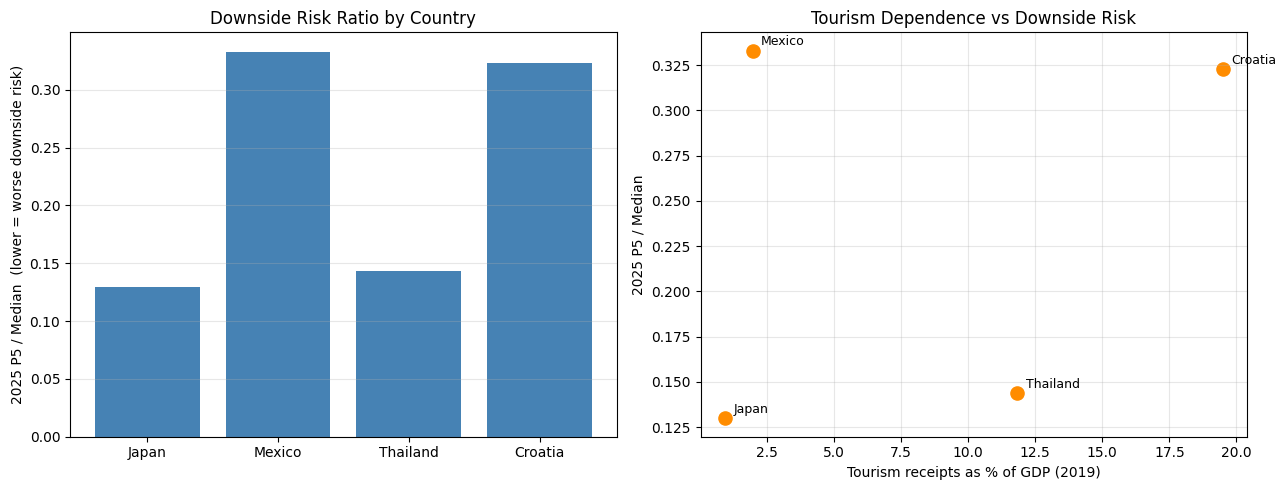

Correlation (tourism dependence vs risk ratio): 0.28


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
x = np.arange(len(summary_df))
ax.bar(x, summary_df['risk_ratio_P5_over_median'], color='steelblue')
ax.set_xticks(x); ax.set_xticklabels(summary_df['country'])
ax.set_ylabel('2025 P5 / Median  (lower = worse downside risk)')
ax.set_title('Downside Risk Ratio by Country')
ax.grid(alpha=0.3, axis='y')

ax2 = axes[1]
ax2.scatter(summary_df['tourism_gdp_share_2019'], summary_df['risk_ratio_P5_over_median'], s=90, color='darkorange')
for _, row in summary_df.iterrows():
    ax2.annotate(row['country'], (row['tourism_gdp_share_2019'], row['risk_ratio_P5_over_median']),
                 textcoords="offset points", xytext=(6, 4), fontsize=9)
ax2.set_xlabel('Tourism receipts as % of GDP (2019)')
ax2.set_ylabel('2025 P5 / Median')
ax2.set_title('Tourism Dependence vs Downside Risk')
ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

corr = summary_df['tourism_gdp_share_2019'].corr(summary_df['risk_ratio_P5_over_median'])
print(f"Correlation (tourism dependence vs risk ratio): {corr:.2f}")

**Takeaway (and a limitation):** With only 4 countries, there's no clean pattern — Mexico and Croatia (very different dependence levels) end up with similar risk, and so do Japan and Thailand. This suggests something else — each country's *own revenue volatility* — might matter as much as tourism dependence. Four countries isn't enough to say for sure, so Part 4 scales this up to 162 countries to get a real answer.

**What this does:** Saves the 4-country comparison table to a CSV file.

**Output:** Prints a confirmation that the file was saved.

In [30]:
summary_df.to_csv('/mnt/user-data/outputs/multi_country_risk_comparison.csv', index=False)
print("Saved multi_country_risk_comparison.csv")

Saved multi_country_risk_comparison.csv


## Part 4: Testing on All 162 Countries
Four countries wasn't enough to answer the question properly, so this repeats the exact same pipeline for every country with good-quality data — 162 out of 216 — to get a reliable answer.

**Quality filter:** a country is only included if it has all 22 years of data, no missing values, positive receipts throughout, no more than 5 suspiciously identical 'flat' early values (a sign of bad back-filled data), and a valid 2019 tourism-GDP share.

**What this does:** Filters the full list of countries down to the 162 that pass the data-quality checks described above.

**Output:** Prints how many countries passed, out of the total.

In [31]:
def get_clean_countries(frame):
    good = []
    for c, g in frame.groupby('country'):
        g = g.sort_values('year')
        if len(g) != 22:
            continue
        cols = ['tourism_receipts', 'gdp', 'inflation', 'tourism_arrivals']
        if g[cols].isna().any().any():
            continue
        if (g['tourism_receipts'] <= 0).any():
            continue
        r = g['tourism_receipts'].values
        flat = 1
        for v in r[1:]:
            if v == r[0]:
                flat += 1
            else:
                break
        if flat > 5:
            continue
        share2019 = g[g.year == 2019]['tourism_gdp_share'].values
        if len(share2019) == 0 or pd.isna(share2019[0]):
            continue
        good.append(c)
    return good

clean_countries = get_clean_countries(model_df)
print(f"Countries passing the data-quality filter: {len(clean_countries)} of {model_df['country'].nunique()}")

Countries passing the data-quality filter: 162 of 216


**Why the code changes here:** Running the same slow simulation loop 162 times (once per country) would take too long, so the Monte Carlo step is rewritten to run as one fast, vectorized calculation instead of a loop. It gives the same results, just much faster (~25 seconds total instead of many minutes).

**What this does:** Runs the fast Monte Carlo simulation for all 162 countries — same idea as Part 2/3 (growth + FX + shock risk), just computed efficiently.

**Output:** A table with each country's best model, tourism-GDP share, revenue volatility, simulated 2025 outcomes, and risk ratio.

In [32]:
def simulate_vectorized(last_actual, mu, sigma, pandemic_center, n_sims=3000, horizon=HORIZON, seed=42):
    rng = np.random.default_rng(seed)
    growths = rng.normal(mu, sigma, size=(n_sims, horizon))
    fx = rng.normal(0, FX_SHOCK_STD, size=(n_sims, horizon))
    shock_mask = rng.random((n_sims, horizon)) < PANDEMIC_PROB
    shock_draw = rng.normal(pandemic_center, 0.15, size=(n_sims, horizon))
    shock_vals = np.where(shock_mask, np.clip(shock_draw, -0.9, -0.05), 0.0)
    multipliers = np.clip((1 + growths) * (1 + fx) * (1 + shock_vals), 0, None)
    return last_actual * np.cumprod(multipliers, axis=1)

full_results = []
for c in clean_countries:
    cts = model_df[model_df['country'] == c].sort_values('year').reset_index(drop=True)
    share2019 = cts[cts.year == 2019]['tourism_gdp_share'].values[0]
    champion = evaluate_models_quiet(cts[cts.year <= 2016], cts[(cts.year > 2016) & (cts.year <= 2019)])[0][0]

    normal_growth = cts[cts.year < 2020]['tourism_receipts'].pct_change().dropna()
    mu, sigma = normal_growth.mean(), normal_growth.std()
    if pd.isna(sigma) or sigma == 0:
        sigma = 0.05
    full_growth = cts['tourism_receipts'].pct_change()
    row2020 = full_growth[cts['year'] == 2020].values
    pandemic_center = row2020[0] if len(row2020) else -0.3
    last_actual = cts['tourism_receipts'].iloc[-1]

    paths = simulate_vectorized(last_actual, mu, sigma, pandemic_center)
    p5, p50, p95 = np.percentile(paths[:, -1], [5, 50, 95])
    full_results.append({
        'country': c, 'tourism_gdp_share_2019': share2019, 'champion_model': champion,
        'growth_sigma': sigma, '2025_P5': p5, '2025_median': p50, '2025_P95': p95,
        'risk_ratio': p5 / p50 if p50 > 0 else np.nan
    })

full_df = pd.DataFrame(full_results).dropna(subset=['risk_ratio'])
print(f"Modeled {len(full_df)} countries")
full_df.head()

Modeled 158 countries


,country,tourism_gdp_share_2019,champion_model,growth_sigma,2025_P5,2025_median,2025_P95,risk_ratio
0,Albania,15.771469,Linear Trend,0.213534,7.172457e+08,2.040172e+09,4.294675e+09,0.351561
1,Angola,0.557139,"ARIMA(1,1,1)",0.476989,5.627830e+05,2.547722e+07,1.402583e+08,0.022090
2,Armenia,11.402943,Linear Trend,0.272007,7.033381e+07,6.084707e+08,1.533061e+09,0.115591
3,Aruba,62.106152,Holt-Winters,0.068336,5.184925e+08,1.299895e+09,1.810385e+09,0.398873
4,Australia,3.443109,Holt-Winters,0.080441,1.522787e+10,3.523212e+10,5.063140e+10,0.432215


**What this does:** Checks how strongly the risk ratio relates to two things: (1) how tourism-dependent a country is, and (2) how volatile (unpredictable) its tourism revenue has historically been. Also runs a simple regression combining both.

**Output:** Printed correlation numbers and regression results showing which factor matters more.

In [33]:
corr_dependence = full_df['tourism_gdp_share_2019'].corr(full_df['risk_ratio'])
corr_volatility = full_df['growth_sigma'].corr(full_df['risk_ratio'])

X = np.column_stack([np.ones(len(full_df)), full_df['tourism_gdp_share_2019'], full_df['growth_sigma']])
y = full_df['risk_ratio'].values
coef, *_ = np.linalg.lstsq(X, y, rcond=None)
resid = y - X @ coef
r_squared = 1 - (resid**2).sum() / ((y - y.mean())**2).sum()

print(f"Correlation: tourism dependence  vs risk ratio = {corr_dependence:+.3f}")
print(f"Correlation: growth volatility   vs risk ratio = {corr_volatility:+.3f}")
print(f"\nTwo-variable regression  risk_ratio ~ tourism_share + growth_sigma:")
print(f"  intercept              = {coef[0]:+.3f}")
print(f"  beta (tourism_share)   = {coef[1]:+.4f}")
print(f"  beta (growth_sigma)    = {coef[2]:+.3f}")
print(f"  R-squared              = {r_squared:.3f}")

Correlation: tourism dependence  vs risk ratio = -0.106
Correlation: growth volatility   vs risk ratio = -0.550

Two-variable regression  risk_ratio ~ tourism_share + growth_sigma:
  intercept              = +0.430
  beta (tourism_share)   = -0.0026
  beta (growth_sigma)    = -0.604
  R-squared              = 0.323


**The real answer:** Across all 162 countries, tourism dependence barely matters (correlation ≈ -0.1, basically noise). What actually predicts downside risk is a country's **own historical revenue volatility** (correlation ≈ -0.55) — how erratic its tourism income has been in the past. In simple terms: a steady, moderately tourism-dependent country can be safer than an unpredictable, less tourism-dependent one. This overturns the assumption that started Part 3.

**What this does:** Draws two scatter plots side by side — tourism dependence vs. risk, and revenue volatility vs. risk — to visually confirm which factor actually matters.

**Output:** Two scatter charts with correlation values in the titles.

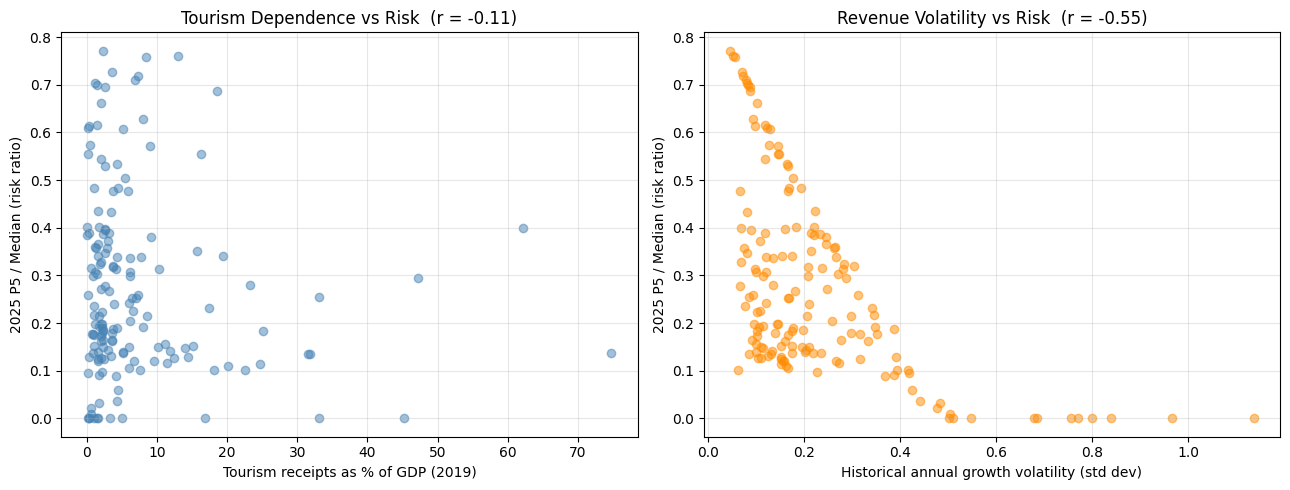

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(full_df['tourism_gdp_share_2019'], full_df['risk_ratio'], alpha=0.5, color='steelblue')
axes[0].set_xlabel('Tourism receipts as % of GDP (2019)')
axes[0].set_ylabel('2025 P5 / Median (risk ratio)')
axes[0].set_title(f'Tourism Dependence vs Risk  (r = {corr_dependence:.2f})')
axes[0].grid(alpha=0.3)

axes[1].scatter(full_df['growth_sigma'], full_df['risk_ratio'], alpha=0.5, color='darkorange')
axes[1].set_xlabel('Historical annual growth volatility (std dev)')
axes[1].set_ylabel('2025 P5 / Median (risk ratio)')
axes[1].set_title(f'Revenue Volatility vs Risk  (r = {corr_volatility:.2f})')
axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

**What this does:** Lists the 8 countries with the worst downside risk (most fragile) and the 8 with the best (most resilient).

**Output:** Two printed tables of country names with their risk numbers.

In [35]:
print("Most fragile (lowest risk ratio -- worst-case 2025 falls closest to zero relative to the median):")
print(full_df.nsmallest(8, 'risk_ratio')[['country','tourism_gdp_share_2019','growth_sigma','risk_ratio']].to_string(index=False))

print("\nMost resilient (highest risk ratio -- narrowest gap between worst-case and median):")
print(full_df.nlargest(8, 'risk_ratio')[['country','tourism_gdp_share_2019','growth_sigma','risk_ratio']].to_string(index=False))

Most fragile (lowest risk ratio -- worst-case 2025 falls closest to zero relative to the median):
            country  tourism_gdp_share_2019  growth_sigma  risk_ratio
           Eswatini                0.311220      0.839365         0.0
              Gabon                0.170080      0.679355         0.0
            Grenada               45.159183      0.508931         0.0
            Lebanon               16.891460      0.800641         0.0
            Myanmar                3.331774      0.684209         0.0
            Nigeria                0.309999      0.755194         0.0
    Solomon Islands                5.064370      0.967350         0.0
St. Kitts and Nevis               33.127062      0.547654         0.0

Most resilient (highest risk ratio -- narrowest gap between worst-case and median):


              country  tourism_gdp_share_2019  growth_sigma  risk_ratio
             Kiribati                2.382649      0.045069    0.771651
              Jamaica               13.012636      0.052401    0.759748
   Dominican Republic                8.501106      0.055265    0.758219
              Iceland                3.569498      0.069904    0.727848
                Malta                7.253121      0.072882    0.718936
Micronesia, Fed. Sts.                6.852792      0.077777    0.710825
               Canada                1.146626      0.079880    0.704042
              Germany                1.475080      0.083386    0.699388


**What this does:** Saves the full 162-country results, sorted by risk, to a final CSV file.

**Output:** Prints a confirmation that the file was saved.

In [36]:
full_df.sort_values('risk_ratio').to_csv('/mnt/user-data/outputs/full_scale_162country_risk.csv', index=False)
print("Saved full_scale_162country_risk.csv")

Saved full_scale_162country_risk.csv
